In [1]:
import torch, torchvision
print(torch.__version__, torchvision.__version__)


2.8.0+cu126 0.23.0+cu126


In [2]:
"""
Q2 — CIFAR-10: ReLU vs Tanh (AlexNet-style figure)
- Two runs of the same 4-layer CNN; only activation differs
- No regularization for this comparison
- LR tuned per activation (as in the paper)
- Early-stop when TRAIN error ≤ 25%
- Record seconds/epoch and plot both trainings on one figure
"""

import os, time, csv, random
from pathlib import Path
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import pandas as pd

# Reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Paths / hyperparams
DATA_ROOT   = "/content/cifar10_data"
OUT_DIR     = Path("./q2_runs"); OUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE  = 128
EPOCHS_CAP  = 200         # upper bound; early-stop should trigger before this
NUM_WORKERS = 2
MOMENTUM    = 0.9
WEIGHT_DECAY= 0.0         # **No regularization** for this figure (important)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [3]:
# Minimal preprocessing so activation effects are clear
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

tf_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
tf_test  = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.CIFAR10(root=DATA_ROOT, train=True,  download=True, transform=tf_train)
test_ds  = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=tf_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train images:", len(train_ds), "| Test images:", len(test_ds))


100%|██████████| 170M/170M [00:05<00:00, 29.6MB/s]


Train images: 50000 | Test images: 10000


In [4]:
"""
Architecture (no BN/Dropout to isolate activation effects):

Block1: Conv(3→64,k3,p1) → Act → Conv(64→64,k3,p1) → Act → MaxPool (32→16)
Block2: Conv(64→128,k3,p1) → Act → Conv(128→128,k3,p1) → Act → MaxPool (16→8)
Head  : Flatten → FC(128*8*8→256) → Act → FC(256→10)

Only 'Act' changes: ReLU vs Tanh.
Initialization: Kaiming(He) for both (keeps all else identical).
"""

class Conv4Net(nn.Module):
    def __init__(self, activation_name="relu", num_classes=10):
        super().__init__()
        act = activation_name.lower()
        if act == "relu":
            self.act = nn.ReLU()
        elif act == "tanh":
            self.act = nn.Tanh()
        else:
            raise ValueError("activation_name must be 'relu' or 'tanh'")

        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2)        # 32 -> 16
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2)        # 16 -> 8
        self.fc1   = nn.Linear(128*8*8, 256)
        self.fc2   = nn.Linear(256, num_classes)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.pool1(x)
        x = self.act(self.conv3(x))
        x = self.act(self.conv4(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = self.act(self.fc1(x))
        x = self.fc2(x)  # logits for CrossEntropyLoss
        return x


In [5]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer, device):
    """
    Train for one epoch; return avg_loss, train_acc, train_err.
    """
    model.train()
    total, correct, running = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running += loss.item() * x.size(0)
        pred = out.argmax(1)
        total += y.size(0)
        correct += (pred == y).sum().item()

    avg_loss = running / total
    acc = correct / total
    err = 1.0 - acc
    return avg_loss, acc, err

@torch.no_grad()
def evaluate(model, loader, device):
    """
    Evaluate on test loader; return avg_loss, acc, err.
    """
    model.eval()
    total, correct, running = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        running += loss.item() * x.size(0)
        pred = out.argmax(1)
        total += y.size(0)
        correct += (pred == y).sum().item()
    avg_loss = running / total
    acc = correct / total
    err = 1.0 - acc
    return avg_loss, acc, err


In [23]:
def run_activation(activation: str, out_dir: Path):
    """
    Train Conv4Net with the given activation.
    - No regularization (weight_decay=0) for this figure.
    - Learning rate tuned per activation (paper: 'chosen independently to train as fast as possible').
      * ReLU:  0.01
      * Tanh:  0.001  (you can try 0.001–0.002 if needed)
    - Early stop when TRAIN error ≤ 0.25
    - Log time per epoch and metrics to CSV
    """
    run_dir = out_dir / activation.lower()
    run_dir.mkdir(parents=True, exist_ok=True)

    set_seed(42)
    model = Conv4Net(activation_name=activation).to(device)

    base_lr = 0.01 if activation.lower() == "relu" else 0.00019
    optimizer = optim.SGD(model.parameters(), lr=base_lr, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

    epoch_times = []
    history_rows = []  # epoch, tr_loss, tr_acc, tr_err, te_loss, te_acc, te_err, epoch_time_sec

    for ep in range(1, EPOCHS_CAP + 1):
        t0 = time.perf_counter()
        tr_loss, tr_acc, tr_err = train_one_epoch(model, train_loader, optimizer, device)
        te_loss, te_acc, te_err = evaluate(model, test_loader, device)
        dt = time.perf_counter() - t0

        epoch_times.append(dt)
        history_rows.append((ep, tr_loss, tr_acc, tr_err, te_loss, te_acc, te_err, dt))
        print(f"[{activation}] ep {ep:03d} | train_err={tr_err:.3f} acc={tr_acc:.3f} | "
              f"test_acc={te_acc:.3f} | {dt:.2f}s")

        if tr_err <= 0.25:  # early-stop criterion
            print(f"[{activation}] Early stop at epoch {ep} (training error ≤ 25%)")
            break

    # Save CSV
    with open(run_dir/"log.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["epoch","train_loss","train_acc","train_err","test_loss","test_acc","test_err","epoch_time_sec"])
        w.writerows(history_rows)

    return epoch_times, history_rows


In [24]:
relu_times, relu_hist = run_activation("ReLU", OUT_DIR)
tanh_times, tanh_hist = run_activation("Tanh", OUT_DIR)

print("ReLU epochs until stop:", len(relu_times))
print("Tanh epochs until stop:", len(tanh_times))


[ReLU] ep 001 | train_err=0.573 acc=0.427 | test_acc=0.542 | 14.25s
[ReLU] ep 002 | train_err=0.396 acc=0.604 | test_acc=0.619 | 14.19s
[ReLU] ep 003 | train_err=0.312 acc=0.688 | test_acc=0.671 | 14.30s
[ReLU] ep 004 | train_err=0.257 acc=0.743 | test_acc=0.710 | 15.02s
[ReLU] ep 005 | train_err=0.207 acc=0.793 | test_acc=0.728 | 14.37s
[ReLU] Early stop at epoch 5 (training error ≤ 25%)
[Tanh] ep 001 | train_err=0.658 acc=0.342 | test_acc=0.421 | 14.67s
[Tanh] ep 002 | train_err=0.557 acc=0.443 | test_acc=0.467 | 14.23s
[Tanh] ep 003 | train_err=0.517 acc=0.483 | test_acc=0.487 | 14.37s
[Tanh] ep 004 | train_err=0.491 acc=0.509 | test_acc=0.511 | 14.85s
[Tanh] ep 005 | train_err=0.468 acc=0.532 | test_acc=0.524 | 14.41s
[Tanh] ep 006 | train_err=0.448 acc=0.552 | test_acc=0.536 | 15.30s
[Tanh] ep 007 | train_err=0.431 acc=0.569 | test_acc=0.554 | 15.00s
[Tanh] ep 008 | train_err=0.416 acc=0.584 | test_acc=0.568 | 14.85s
[Tanh] ep 009 | train_err=0.402 acc=0.598 | test_acc=0.579 | 14.

Saved figure to: q2_runs/q2_combined_error_and_time.png


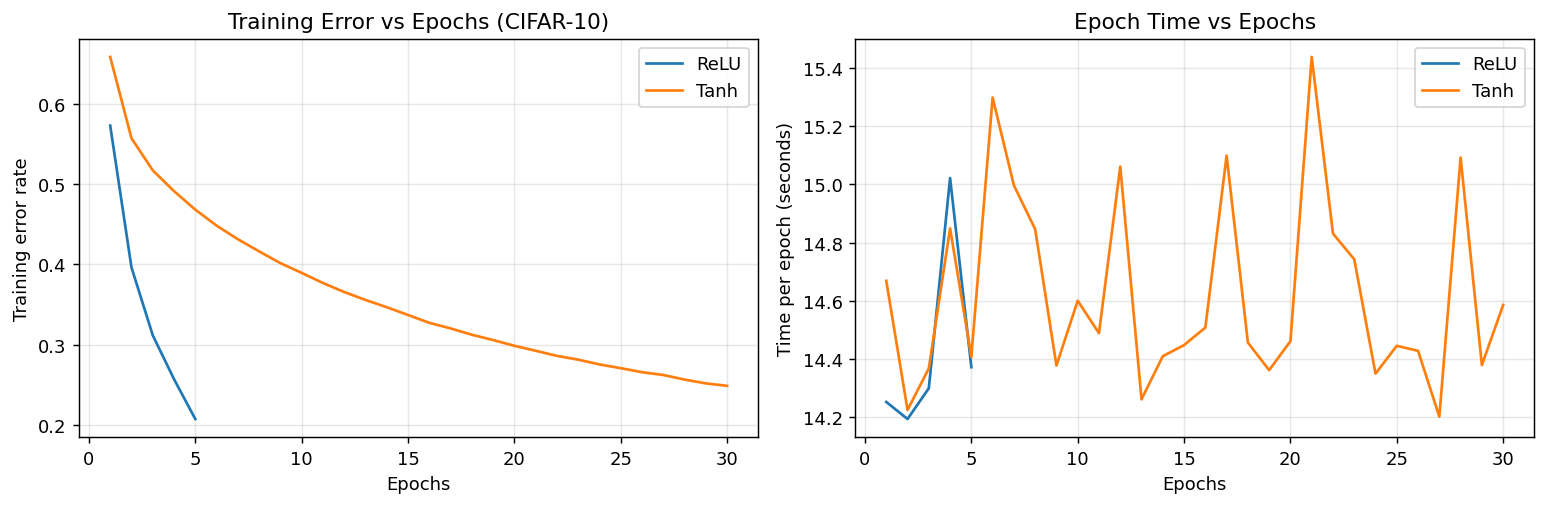

In [25]:
OUT = Path("./q2_runs")
relu_df = pd.read_csv(OUT/"relu"/"log.csv")
tanh_df = pd.read_csv(OUT/"tanh"/"log.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=130)

# (A) Training error vs epochs (mirrors the AlexNet figure)
axes[0].plot(relu_df["epoch"], relu_df["train_err"], label="ReLU")
axes[0].plot(tanh_df["epoch"], tanh_df["train_err"], label="Tanh")
axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Training error rate")
axes[0].set_title("Training Error vs Epochs (CIFAR-10)")
axes[0].grid(True, alpha=0.3); axes[0].legend()

# (B) Seconds per epoch vs epochs (assignment's timing plot)
axes[1].plot(relu_df["epoch"], relu_df["epoch_time_sec"], label="ReLU")
axes[1].plot(tanh_df["epoch"], tanh_df["epoch_time_sec"], label="Tanh")
axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Time per epoch (seconds)")
axes[1].set_title("Epoch Time vs Epochs")
axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
save_path = OUT/"q2_combined_error_and_time.png"
plt.savefig(save_path)
print("Saved figure to:", save_path)


Saved: q2_runs/q2_time_only.png


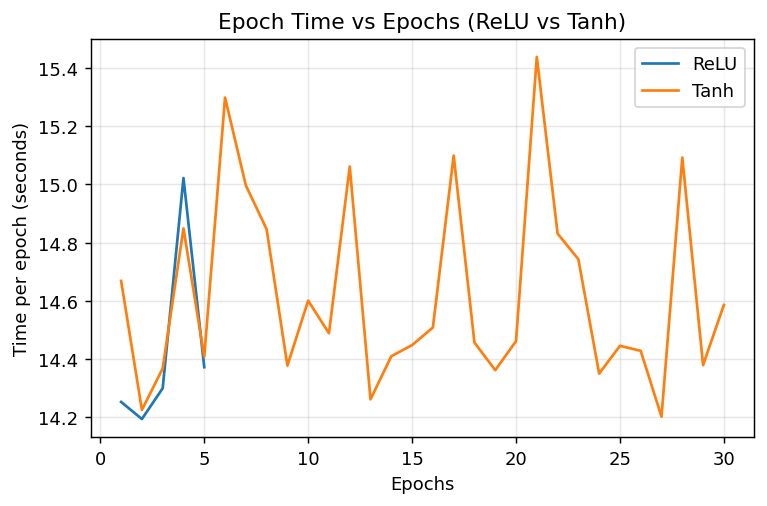

In [26]:
plt.figure(figsize=(6,4), dpi=130)
plt.plot(relu_df["epoch"], relu_df["epoch_time_sec"], label="ReLU")
plt.plot(tanh_df["epoch"], tanh_df["epoch_time_sec"], label="Tanh")
plt.xlabel("Epochs"); plt.ylabel("Time per epoch (seconds)")
plt.title("Epoch Time vs Epochs (ReLU vs Tanh)")
plt.grid(True, alpha=0.3); plt.legend()
path_time = OUT_DIR/"q2_time_only.png"
plt.tight_layout(); plt.savefig(path_time)
print("Saved:", path_time)


In [27]:
relu_df = pd.read_csv(OUT_DIR/"relu"/"log.csv")
tanh_df = pd.read_csv(OUT_DIR/"tanh"/"log.csv")

relu_stop = int(relu_df["epoch"].iloc[-1])
tanh_stop = int(tanh_df["epoch"].iloc[-1])
ratio = tanh_stop / relu_stop if relu_stop > 0 else float("inf")

print(f"ReLU stop epoch   : {relu_stop}")
print(f"Tanh stop epoch   : {tanh_stop}")
print(f"Epoch multiple    : Tanh / ReLU = {ratio:.2f}×")

print("\nFinal-row metrics:")
print("ReLU  -> train_err={:.3f}, train_acc={:.3f}, test_acc={:.3f}"
      .format(relu_df['train_err'].iloc[-1], relu_df['train_acc'].iloc[-1], relu_df['test_acc'].iloc[-1]))
print("Tanh  -> train_err={:.3f}, train_acc={:.3f}, test_acc={:.3f}"
      .format(tanh_df['train_err'].iloc[-1], tanh_df['train_acc'].iloc[-1], tanh_df['test_acc'].iloc[-1]))


ReLU stop epoch   : 5
Tanh stop epoch   : 30
Epoch multiple    : Tanh / ReLU = 6.00×

Final-row metrics:
ReLU  -> train_err=0.207, train_acc=0.793, test_acc=0.728
Tanh  -> train_err=0.249, train_acc=0.751, test_acc=0.684
